In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
try:
    path = '../../2.0-dados-abertos-UFRN/1-limpeza-de-dados/databases/turmas.csv'
    df = pd.read_csv(path)
except Exception as e:
    print(f"Erro ao carregar dados: {e}")

/tmp/ipykernel_17118/3436370270.py:3: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [13]:
df.info()
print('\n')
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336871 entries, 0 to 336870
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id_turma                   336871 non-null  int64  
 1   codigo_turma               336871 non-null  object 
 2   siape                      325003 non-null  float64
 3   matricula_docente_externo  11829 non-null   float64
 4   observacao                 12016 non-null   object 
 5   id_componente_curricular   336871 non-null  int64  
 6   ch_dedicada_periodo        336871 non-null  int64  
 7   nivel_ensino               336871 non-null  object 
 8   campus_turma               252817 non-null  object 
 9   local                      332657 non-null  object 
 10  ano                        336871 non-null  int64  
 11  periodo                    336871 non-null  int64  
 12  data_inicio                336871 non-null  object 
 13  data_fim                   33

,id_turma,siape,matricula_docente_externo,id_componente_curricular,ch_dedicada_periodo,ano,periodo,total_solicitacoes,capacidade_aluno,id_turma_agrupadora,qtd_aulas_lancadas
count,3.368710e+05,3.250030e+05,11829.000000,3.368710e+05,336871.000000,336871.000000,336871.000000,296391.000000,324800.000000,1.864300e+04,288093.000000
mean,4.684827e+07,2.087996e+06,36968.025953,2.696527e+05,30.865334,2018.505131,1.634988,17.077128,24.610351,4.177807e+07,78.812429
std,2.220566e+07,1.203033e+06,34036.844514,6.201758e+05,25.538292,3.470039,0.923543,20.991562,28.113433,2.537074e+07,83.640179
min,1.195081e+06,0.000000e+00,310.000000,1.864700e+04,0.000000,2013.000000,1.000000,0.000000,0.000000,1.197043e+06,0.000000
25%,5.757334e+07,1.281099e+06,7834.000000,4.666100e+04,10.000000,2015.000000,1.000000,4.000000,6.000000,1.239811e+06,35.000000
50%,5.763086e+07,1.885001e+06,12622.000000,5.814000e+04,30.000000,2018.000000,2.000000,9.000000,20.000000,5.760635e+07,66.000000
75%,5.769473e+07,2.569445e+06,72473.000000,6.618600e+04,60.000000,2022.000000,2.000000,25.000000,40.000000,5.767754e+07,78.000000
max,5.776030e+07,9.350807e+06,83636.000000,2.056255e+06,720.000000,2024.000000,6.000000,930.000000,1534.000000,5.775810e+07,1064.000000



--- Distribuição da Situação da Turma ---


/tmp/ipykernel_17118/2567826393.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=situacao_counts.index, y=situacao_counts.values, palette="viridis")


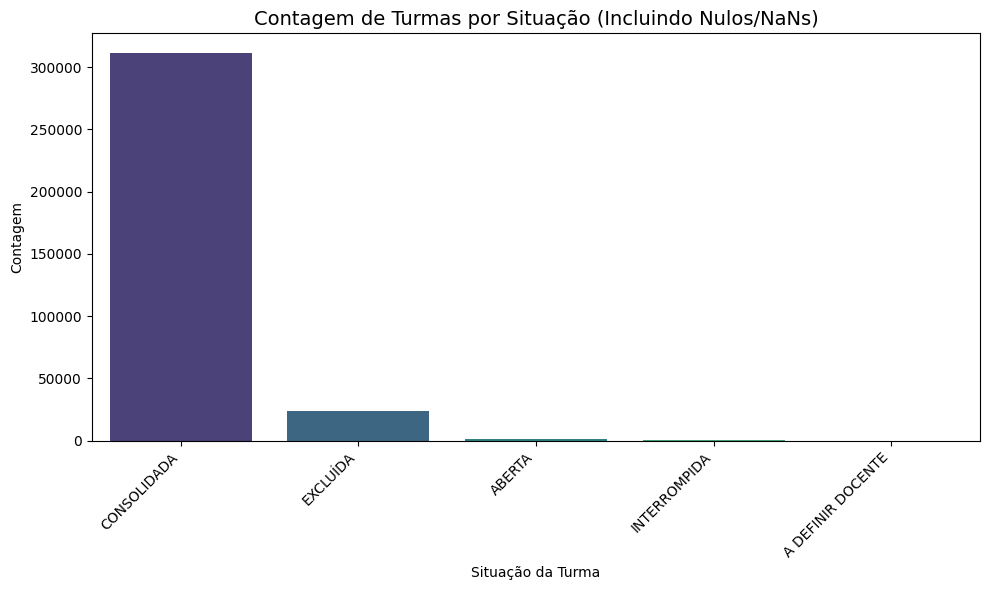

In [6]:
# gráfico da distribuição da Situação da Turma ('situacao_turma')
if 'situacao_turma' in df.columns:
    print("\n--- Distribuição da Situação da Turma ---")
    plt.figure(figsize=(10, 6))
    situacao_counts = df['situacao_turma'].value_counts(dropna=False)
    sns.barplot(x=situacao_counts.index, y=situacao_counts.values, palette="viridis")
    plt.title('Contagem de Turmas por Situação (Incluindo Nulos/NaNs)', fontsize=14)
    plt.xlabel('Situação da Turma')
    plt.ylabel('Contagem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


--- Distribuição do Nível de Ensino ---


/tmp/ipykernel_17118/1590421929.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=niveis.index, y=niveis.values, palette="mako")


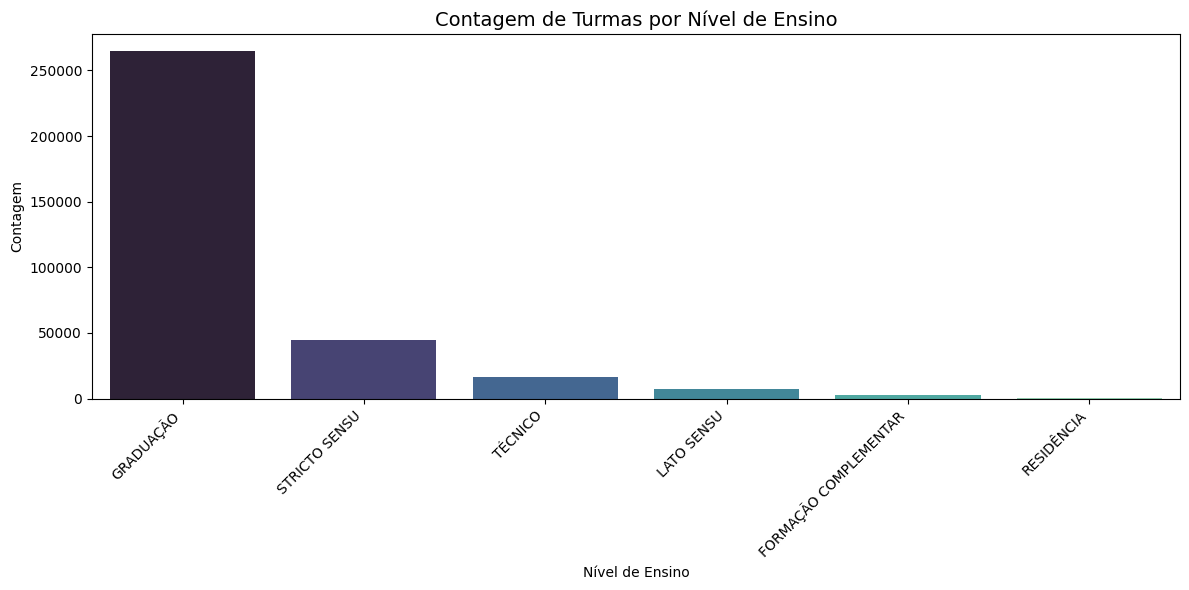

In [7]:
# gráfico de distribuição por Nível de Ensino
if 'nivel_ensino' in df.columns:
    print("\n--- Distribuição do Nível de Ensino ---")
    plt.figure(figsize=(12, 6))
    niveis = df['nivel_ensino'].value_counts(dropna=False).head(6)
    sns.barplot(x=niveis.index, y=niveis.values, palette="mako")
    plt.title('Contagem de Turmas por Nível de Ensino', fontsize=14)
    plt.xlabel('Nível de Ensino')
    plt.ylabel('Contagem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


--- Contagem de Turmas por Situação e Ano de Início ---


ano_inicio
2012        3
2013    26226
2014    28715
2015    29524
2016    28880
2017    28274
2018    30493
2019    30655
2020    18846
2021    25818
2022    30275
2023    29629
2024    29299
2025      234
dtype: int64

<Figure size 1400x700 with 0 Axes>

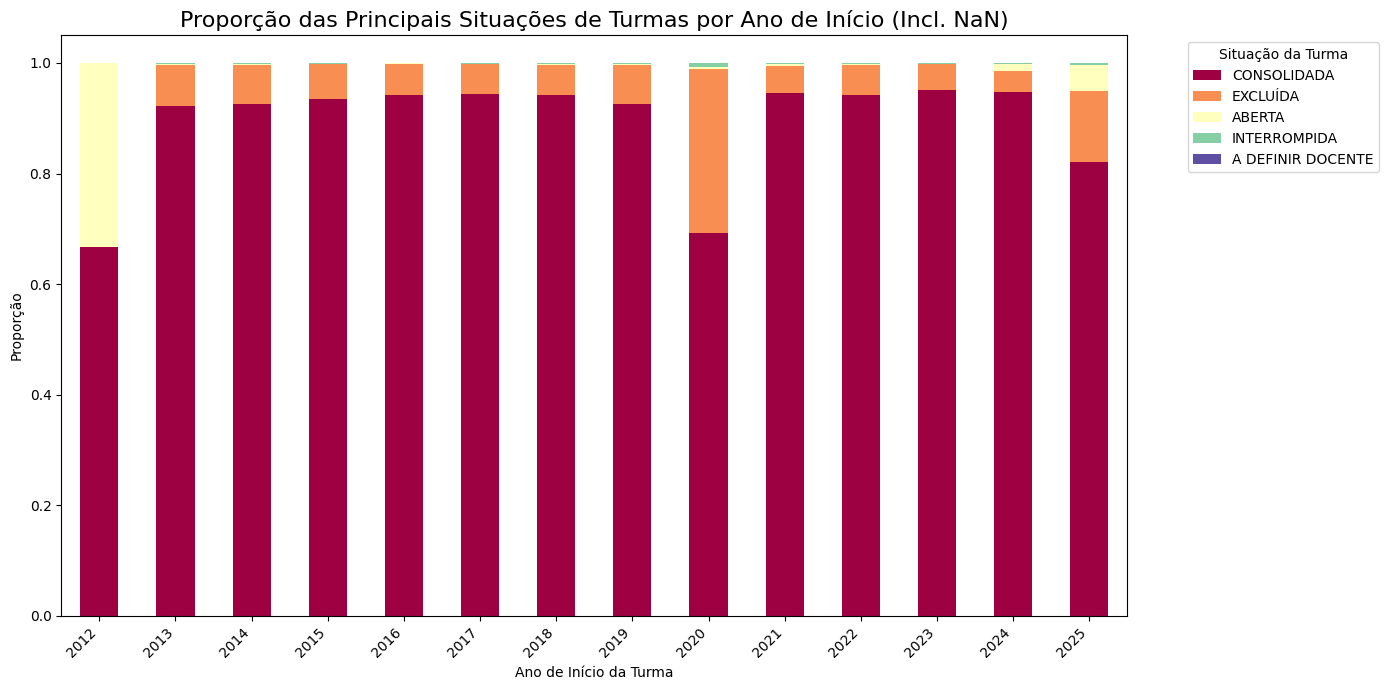

In [8]:
# análise temporal
if ('data_inicio' in df.columns) and ('situacao_turma' in df.columns):
    try:
        df_temp = df.copy()
        df_temp['data_inicio_dt'] = pd.to_datetime(df_temp['data_inicio'], errors='coerce')
        df_temp['ano_inicio'] = df_temp['data_inicio_dt'].dt.year

        ct_ano_situacao = pd.crosstab(df_temp['ano_inicio'], df_temp['situacao_turma'], dropna=False)
        print("\n--- Contagem de Turmas por Situação e Ano de Início ---")
        display(ct_ano_situacao.sum(axis=1).sort_index())

        top_situacoes = df_temp['situacao_turma'].value_counts(dropna=False).head(5).index
        ct_top = ct_ano_situacao[top_situacoes].sort_index()

        ct_top_norm = ct_top.div(ct_top.sum(axis=1), axis=0)

        plt.figure(figsize=(14, 7))
        ct_top_norm.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='Spectral')
        plt.title('Proporção das Principais Situações de Turmas por Ano de Início (Incl. NaN)', fontsize=16)
        plt.xlabel('Ano de Início da Turma')
        plt.ylabel('Proporção')
        plt.legend(title='Situação da Turma', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"\n[AVISO]: Não foi possível gerar a análise temporal. Erro: {e}")


--- Contagem de Turmas por Situação e Nível de Ensino ---


<Figure size 1200x700 with 0 Axes>

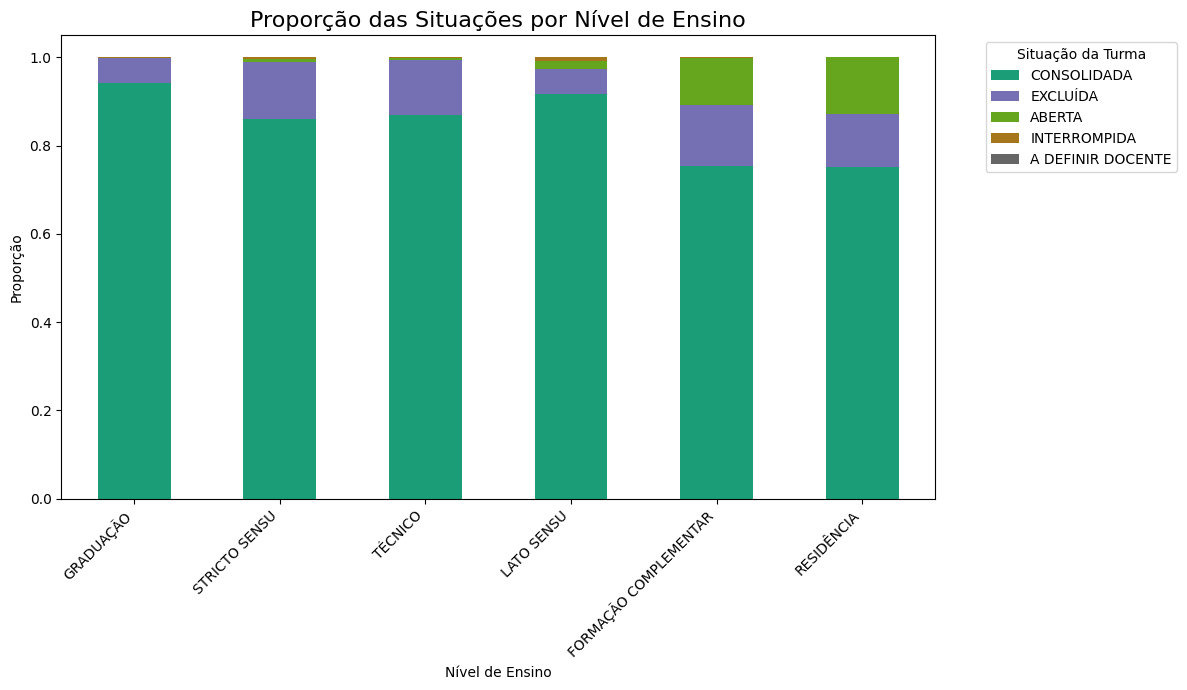

In [9]:
# proporção da situação da turma por Nível de Ensino ('nivel_ensino')
if ('nivel_ensino' in df.columns) and ('situacao_turma' in df.columns):

    ct_nivel_situacao = pd.crosstab(df['nivel_ensino'], df['situacao_turma'], dropna=False)
    print("\n--- Contagem de Turmas por Situação e Nível de Ensino ---")

    top_niveis = df['nivel_ensino'].value_counts(dropna=False).head(6).index
    top_situacoes_all = df['situacao_turma'].value_counts(dropna=False).head(5).index

    if len(top_situacoes_all) > 0:
        ct_top_nivel = ct_nivel_situacao.loc[top_niveis, top_situacoes_all]

        ct_top_nivel_norm = ct_top_nivel.div(ct_top_nivel.sum(axis=1), axis=0)

        plt.figure(figsize=(12, 7))
        ct_top_nivel_norm.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='Dark2')
        plt.title('Proporção das Situações por Nível de Ensino', fontsize=16)
        plt.xlabel('Nível de Ensino')
        plt.ylabel('Proporção')
        plt.legend(title='Situação da Turma', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


--- Estatísticas da Diferença (Capacidade - Solicitações) ---


count    289727.000000
mean          7.551398
std          21.435292
min        -521.000000
25%           0.000000
50%           2.000000
75%          12.000000
max        1493.000000
dtype: float64

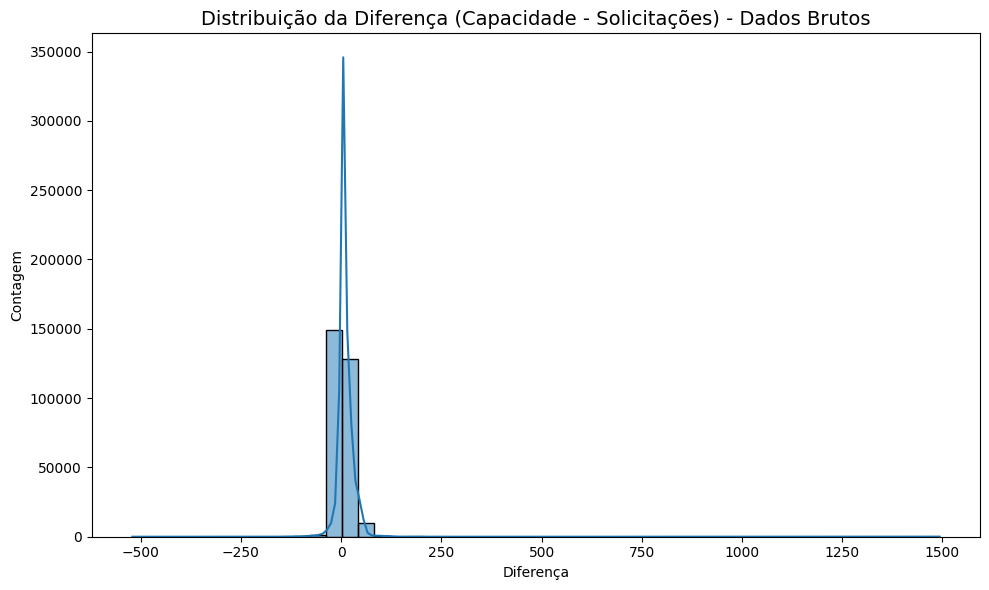

In [10]:
# comparação entre a capacidade e as solicitações
if ('capacidade_aluno' in df.columns) and ('total_solicitacoes' in df.columns):

    diferenca_capacidade = df['capacidade_aluno'] - df['total_solicitacoes']

    print("\n--- Estatísticas da Diferença (Capacidade - Solicitações) ---")
    display(diferenca_capacidade.describe())

    plt.figure(figsize=(10, 6))
    sns.histplot(diferenca_capacidade, bins=50, kde=True)
    plt.title('Distribuição da Diferença (Capacidade - Solicitações) - Dados Brutos', fontsize=14)
    plt.xlabel('Diferença')
    plt.ylabel('Contagem')
    plt.tight_layout()
    plt.show()